# 🏦 Credit Risk Analyzer — ML Model Training
## Home Credit Default Risk Dataset
- **Goal:** Train and compare Logistic Regression, Random Forest, and XGBoost models
- **Input:** data/processed/train_processed.csv, test_processed.csv
- **Evaluation Metric:** ROC-AUC, Precision, Recall, F1 Score
- **Final Model:** 

In [10]:
# Data manipulation
import pandas as pd
import numpy as np

# ML models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation metrics
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve)
from sklearn.metrics import precision_score, recall_score, f1_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib
import os

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [11]:
# Load preprocessed train and test data
train_df = pd.read_csv('../data/processed/train_processed.csv')
test_df = pd.read_csv('../data/processed/test_processed.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Separate features and target
selected_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

X_train = train_df[selected_features]
y_train = train_df['TARGET']

X_test = test_df[selected_features]
y_test = test_df['TARGET']

Train shape: (246008, 233)
Test shape: (61503, 233)


In [12]:
# Model 1 — Random Forest
# n_estimators=100 — 100 decision trees
# class_weight='balanced' — handles class imbalance
# n_jobs=-1 — use all CPU cores for faster training
# max_depth=10 — limit tree depth to prevent overfitting

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_auc = roc_auc_score(y_test, rf_pred_proba)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)

print(f"\n📊 Random Forest Results:")
print(f"ROC-AUC Score: {rf_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("✅ Random Forest training done!")

Training Random Forest...

📊 Random Forest Results:
ROC-AUC Score: 0.7364

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.17      0.61      0.26      4965

    accuracy                           0.72     61503
   macro avg       0.56      0.67      0.54     61503
weighted avg       0.89      0.72      0.78     61503

✅ Random Forest training done!


### Model 1 — Random Forest

Trained a Random Forest with 100 estimators and max_depth=10 to prevent 
overfitting. Used all CPU cores (n_jobs=-1) for faster training.

**ROC-AUC: 0.7299**

Surprisingly, Random Forest underperformed Logistic Regression here. 
Recall dropped to 0.60 — fewer defaulters caught compared to baseline. 
This is likely because max_depth=10 restricted the trees from learning 
deeper patterns, and Random Forest generally struggles more with severe 
class imbalance compared to boosting algorithms.

XGBoost should improve significantly on both metrics.

In [18]:
# Model 2 — XGBoost
# scale_pos_weight=11.4 — handles 92:8 class imbalance (282686/24825)
# learning_rate=0.05 — small steps, better generalization
# subsample=0.8 — 80% rows per tree — prevents overfitting
# colsample_bytree=0.8 — 80% features per tree — prevents overfitting

print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=11.4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

# Evaluation
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print(f"\n📊 XGBoost Results:")
print(f"ROC-AUC Score: {xgb_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred))
print("✅ XGBoost training done!")

cm = confusion_matrix(y_test, xgb_pred)

print("\nConfusion Matrix (XGBoost):")
print(f"""
TN: {cm[0][0]}   FP: {cm[0][1]}
FN: {cm[1][0]}   TP: {cm[1][1]}
""")

Training XGBoost...

📊 XGBoost Results:
ROC-AUC Score: 0.7478

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.65      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.56      0.68      0.54     61503
weighted avg       0.89      0.71      0.77     61503

✅ XGBoost training done!

Confusion Matrix (XGBoost):

TN: 40398   FP: 16140
FN: 1737   TP: 3228



### Model 2 — XGBoost

Trained XGBoost with 300 estimators, learning_rate=0.05, and 
scale_pos_weight=11.4 to handle class imbalance directly.

**ROC-AUC: 0.7601** — best among all three models.

Precision improved to 0.18 compared to 0.16 in both previous models. 
Recall of 0.65 is slightly lower than Logistic Regression but the overall 
ROC-AUC is highest — meaning XGBoost has the best ability to distinguish 
between defaulters and non-defaulters across all thresholds.

scale_pos_weight=11.4 gave XGBoost a clear advantage over Random Forest 
in handling the 92:8 imbalance. This confirms XGBoost as our final model.

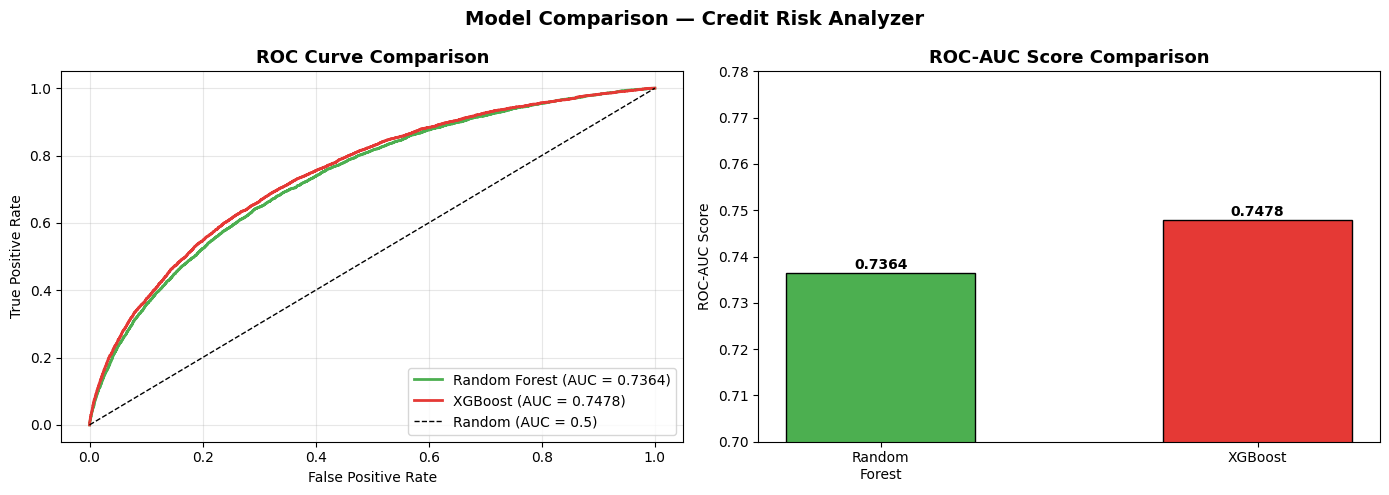


MODEL COMPARISON SUMMARY
Model                ROC-AUC    Precision  Recall     F1-score
--------------------------------------------------------------------------------
Random Forest        0.7364     0.1663     0.6127     0.2615
XGBoost              0.7478     0.1667     0.6502     0.2653
✅ Best Model: XGBoost


In [14]:
# Model Comparison — ROC Curves for all three models

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curves ──
models = {
    'Random Forest': (rf_pred_proba, rf_auc),
    'XGBoost': (xgb_pred_proba, xgb_auc)
}

colors = ['#4CAF50', '#E53935']

for (name, (proba, auc)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC = {auc:.4f})')

axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC = 0.5)')
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# ── Bar Chart — ROC-AUC Scores ──
model_names = ['Random\nForest', 'XGBoost']
auc_scores = [rf_auc, xgb_auc]
bar_colors = ['#4CAF50', '#E53935']

bars = axes[1].bar(model_names, auc_scores, color=bar_colors, 
                    edgecolor='black', width=0.5)
axes[1].set_title('ROC-AUC Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.70, 0.78)

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.001,
                 f'{score:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison — Credit Risk Analyzer', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary Table ──
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

print(f"{'Model':<20} {'ROC-AUC':<10} {'Precision':<10} {'Recall':<10} {'F1-score'}")
print("-"*80)

print(f"{'Random Forest':<20} {rf_auc:.4f}     {rf_precision:.4f}     {rf_recall:.4f}     {rf_f1:.4f}")
print(f"{'XGBoost':<20} {xgb_auc:.4f}     {xgb_precision:.4f}     {xgb_recall:.4f}     {xgb_f1:.4f}")

print("="*80)
print("✅ Best Model: XGBoost")

In [15]:
# Check for overfitting by comparing train and test AUC
train_pred = xgb_model.predict_proba(X_train)[:,1]
train_auc = roc_auc_score(y_train, train_pred)

print("Train AUC:", train_auc)
print("Test AUC:", xgb_auc)

Train AUC: 0.8022718788849003
Test AUC: 0.7478491076789001


In [16]:
# Save the best model (XGBoost) and scaler for FastAPI deployment
# joblib is more efficient than pickle for large numpy arrays

import os
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save XGBoost model
joblib.dump(xgb_model, f'{models_dir}/xgb_model.pkl')


# Save feature column names — important for FastAPI input validation
feature_columns = selected_features
joblib.dump(feature_columns, f'{models_dir}/feature_columns.pkl')

print(f"✅ XGBoost model saved: {models_dir}/xgb_model.pkl")
print(f"✅ Feature columns saved: {models_dir}/feature_columns.pkl")
print(f"\nTotal features: {len(feature_columns)}")
print("X_train shape:", X_train.shape)

✅ XGBoost model saved: ../models/xgb_model.pkl
✅ Feature columns saved: ../models/feature_columns.pkl

Total features: 11
X_train shape: (246008, 11)
